In [4]:
import pandas as pd

data = {
    "Crop": ["Rice", "Wheat", "Maize", "Cotton", "Tomato"],
    "Soil_N": [40, 35, 45, 30, 50],
    "Soil_P": [25, 20, 30, 18, 35],
    "Soil_K": [35, 30, 40, 25, 45],
    "pH": [6.5, 6.8, 6.2, 7.0, 6.0],
    "Moisture": [55, 50, 60, 45, 65]
}

df = pd.DataFrame(data)

print(df)

     Crop  Soil_N  Soil_P  Soil_K   pH  Moisture
0    Rice      40      25      35  6.5        55
1   Wheat      35      20      30  6.8        50
2   Maize      45      30      40  6.2        60
3  Cotton      30      18      25  7.0        45
4  Tomato      50      35      45  6.0        65


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("All libraries are working!")

All libraries are working!


In [2]:
import pandas as pd
import numpy as np
print("Everything is working!")

Everything is working!


In [5]:
# Calculate fertilizer nutrient deficiency

TARGET_N = 100
TARGET_P = 50
TARGET_K = 80

df["N_Required"] = (TARGET_N - df["Soil_N"]).clip(lower=0)
df["P_Required"] = (TARGET_P - df["Soil_P"]).clip(lower=0)
df["K_Required"] = (TARGET_K - df["Soil_K"]).clip(lower=0)

print(df)

     Crop  Soil_N  Soil_P  Soil_K   pH  Moisture  N_Required  P_Required  \
0    Rice      40      25      35  6.5        55          60          25   
1   Wheat      35      20      30  6.8        50          65          30   
2   Maize      45      30      40  6.2        60          55          20   
3  Cotton      30      18      25  7.0        45          70          32   
4  Tomato      50      35      45  6.0        65          50          15   

   K_Required  
0          45  
1          50  
2          40  
3          55  
4          35  


In [6]:
# Simple fertilizer recommendation

def recommend_fertilizer(row):
    recommendations = []

    if row["N_Required"] > 0:
        recommendations.append("Urea")
    if row["P_Required"] > 0:
        recommendations.append("DAP")
    if row["K_Required"] > 0:
        recommendations.append("MOP")

    return ", ".join(recommendations)

df["Recommended_Fertilizer"] = df.apply(recommend_fertilizer, axis=1)

print(df[["Crop", "N_Required", "P_Required", "K_Required",
          "Recommended_Fertilizer"]])

     Crop  N_Required  P_Required  K_Required Recommended_Fertilizer
0    Rice          60          25          45         Urea, DAP, MOP
1   Wheat          65          30          50         Urea, DAP, MOP
2   Maize          55          20          40         Urea, DAP, MOP
3  Cotton          70          32          55         Urea, DAP, MOP
4  Tomato          50          15          35         Urea, DAP, MOP


In [7]:
# Calculate estimated fertilizer quantities (kg/acre)

df["Urea_kg"] = df["N_Required"] / 0.46
df["DAP_kg"] = df["P_Required"] / 0.46
df["MOP_kg"] = df["K_Required"] / 0.60

# Round the values
df["Urea_kg"] = df["Urea_kg"].round(2)
df["DAP_kg"] = df["DAP_kg"].round(2)
df["MOP_kg"] = df["MOP_kg"].round(2)

print(df[[
    "Crop",
    "Urea_kg",
    "DAP_kg",
    "MOP_kg"
]])

     Crop  Urea_kg  DAP_kg  MOP_kg
0    Rice   130.43   54.35   75.00
1   Wheat   141.30   65.22   83.33
2   Maize   119.57   43.48   66.67
3  Cotton   152.17   69.57   91.67
4  Tomato   108.70   32.61   58.33


In [1]:
import sys
print(sys.executable)

c:\Users\Dell\OneDrive\Documents\sustainable-fertilizer-optimizer\venv\Scripts\python.exe


In [8]:
# Sustainability score calculation

# Lower fertilizer usage = better sustainability
df["Total_Fertilizer_kg"] = (
    df["Urea_kg"] +
    df["DAP_kg"] +
    df["MOP_kg"]
)

# Simple sustainability score out of 100
MAX_FERTILIZER = df["Total_Fertilizer_kg"].max()

df["Sustainability_Score"] = (
    100 - (df["Total_Fertilizer_kg"] / MAX_FERTILIZER * 50)
).round(2)

print(df[[
    "Crop",
    "Total_Fertilizer_kg",
    "Sustainability_Score"
]])

     Crop  Total_Fertilizer_kg  Sustainability_Score
0    Rice               259.78                 58.56
1   Wheat               289.85                 53.76
2   Maize               229.72                 63.35
3  Cotton               313.41                 50.00
4  Tomato               199.64                 68.15


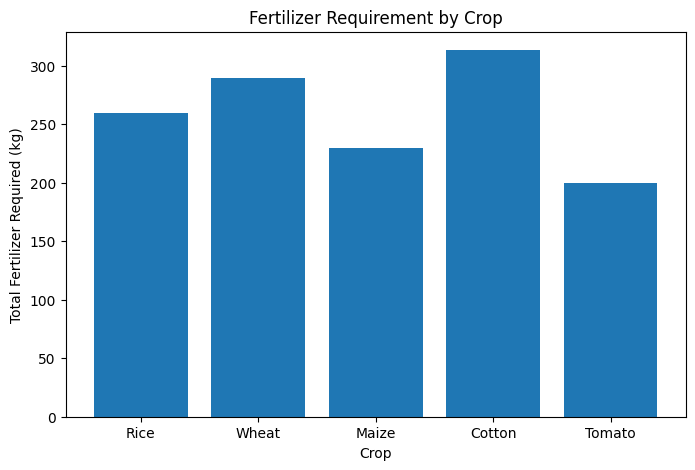

In [9]:
import matplotlib.pyplot as plt

# Bar chart of total fertilizer required
plt.figure(figsize=(8, 5))

plt.bar(df["Crop"], df["Total_Fertilizer_kg"])

plt.xlabel("Crop")
plt.ylabel("Total Fertilizer Required (kg)")
plt.title("Fertilizer Requirement by Crop")

plt.show()

In [10]:
def fertilizer_optimizer(crop, soil_n, soil_p, soil_k):
    
    TARGET_N = 100
    TARGET_P = 50
    TARGET_K = 80

    # Calculate nutrient deficiency
    n_required = max(TARGET_N - soil_n, 0)
    p_required = max(TARGET_P - soil_p, 0)
    k_required = max(TARGET_K - soil_k, 0)

    # Calculate fertilizer quantities
    urea_kg = round(n_required / 0.46, 2)
    dap_kg = round(p_required / 0.46, 2)
    mop_kg = round(k_required / 0.60, 2)

    print("🌱 SUSTAINABLE FERTILIZER OPTIMIZER")
    print("-" * 40)
    print("Crop:", crop)
    print("Soil N:", soil_n)
    print("Soil P:", soil_p)
    print("Soil K:", soil_k)

    print("\nRecommended Fertilizer:")
    print("Urea:", urea_kg, "kg")
    print("DAP:", dap_kg, "kg")
    print("MOP:", mop_kg, "kg")

In [11]:
fertilizer_optimizer(
    crop="Rice",
    soil_n=40,
    soil_p=25,
    soil_k=35
)

🌱 SUSTAINABLE FERTILIZER OPTIMIZER
----------------------------------------
Crop: Rice
Soil N: 40
Soil P: 25
Soil K: 35

Recommended Fertilizer:
Urea: 130.43 kg
DAP: 54.35 kg
MOP: 75.0 kg


In [1]:
crop = "Rice"
soil_n = 40
soil_p = 25
soil_k = 35

fertilizer_optimizer(crop, soil_n, soil_p, soil_k)

NameError: name 'fertilizer_optimizer' is not defined

In [2]:
def fertilizer_optimizer(crop, soil_n, soil_p, soil_k):
    
    TARGET_N = 100
    TARGET_P = 50
    TARGET_K = 80

    n_required = max(TARGET_N - soil_n, 0)
    p_required = max(TARGET_P - soil_p, 0)
    k_required = max(TARGET_K - soil_k, 0)

    urea_kg = round(n_required / 0.46, 2)
    dap_kg = round(p_required / 0.46, 2)
    mop_kg = round(k_required / 0.60, 2)

    print("SUSTAINABLE FERTILIZER OPTIMIZER")
    print("-" * 40)
    print("Crop:", crop)
    print("Soil N:", soil_n)
    print("Soil P:", soil_p)
    print("Soil K:", soil_k)

    print("\nRecommended Fertilizer:")
    print("Urea:", urea_kg, "kg")
    print("DAP:", dap_kg, "kg")
    print("MOP:", mop_kg, "kg")

In [3]:
fertilizer_optimizer("Rice", 40, 25, 35)

SUSTAINABLE FERTILIZER OPTIMIZER
----------------------------------------
Crop: Rice
Soil N: 40
Soil P: 25
Soil K: 35

Recommended Fertilizer:
Urea: 130.43 kg
DAP: 54.35 kg
MOP: 75.0 kg
